In [15]:
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
df = pd.read_csv('articles_annotated.csv')

In [18]:
df.head()

,date,title,description,coding
0,2024-11-27,xAI is reportedly launching a ChatGPT-like app...,Elon Musk's xAI reportedly plans to launch a c...,Side Ventures
1,2024-11-27,"Starlink gets FCC nod for space calls, but can...",Authorization conditional on operations not ca...,Space Exploration
2,2024-11-27,T-Mobile And SpaceX Satellite-To-Phone Project...,"In remote locations, this means your phone mig...",Space Exploration
3,2024-11-27,Kim Kardashian denies Tesla paid her to pose w...,The reality star raised eyebrows with a futuri...,Electric Vehicles
4,2024-11-27,xAI is reportedly launching a ChatGPT-like app...,Elon Musk's xAI could reportedly launch an app...,Side Ventures


In [19]:
codings = df['coding'].unique()
codings

array(['Side Ventures', 'Space Exploration', 'Electric Vehicles',
       'Politics', 'Association with Trump', 'X'], dtype=object)

In [20]:
df['text'] = df['title'] + " " + df['description']

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

# Define custom stop words
custom_stop_words = ['elon', 'musk', 'donald', 'jay', 'alex']

# Add all numbers from 1 to 100 to the custom stop words
numeric_stop_words = [str(i) for i in range(1, 101)]
custom_stop_words.extend(numeric_stop_words)

# Extend the default English stop words with custom stop words
tfidf_vectorizer = TfidfVectorizer(stop_words='english')
default_stop_words = tfidf_vectorizer.get_stop_words()
all_stop_words = list(set(default_stop_words).union(custom_stop_words))  # Convert to a list

# Create a new TfidfVectorizer with the updated stop words
tfidf_vectorizer = TfidfVectorizer(stop_words=all_stop_words)

# Fit and transform the text column
tfidf_matrix = tfidf_vectorizer.fit_transform(df['text'])

# Create the DataFrame
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out(),
    index=df['coding']
)

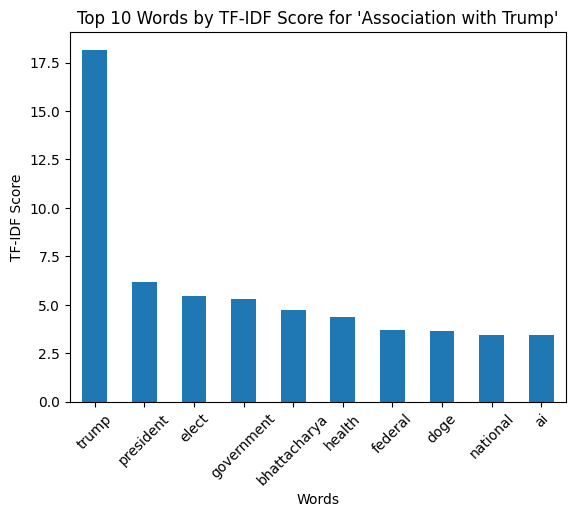

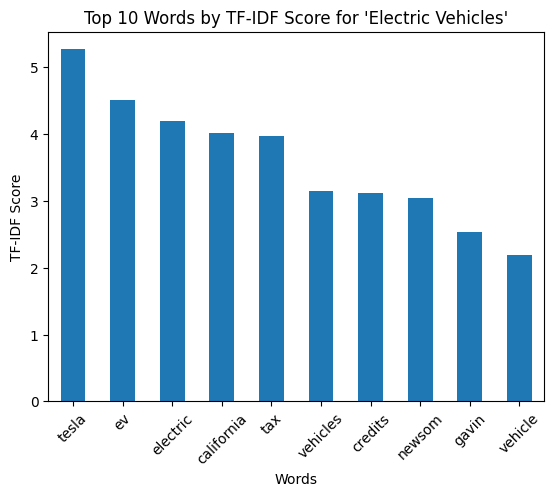

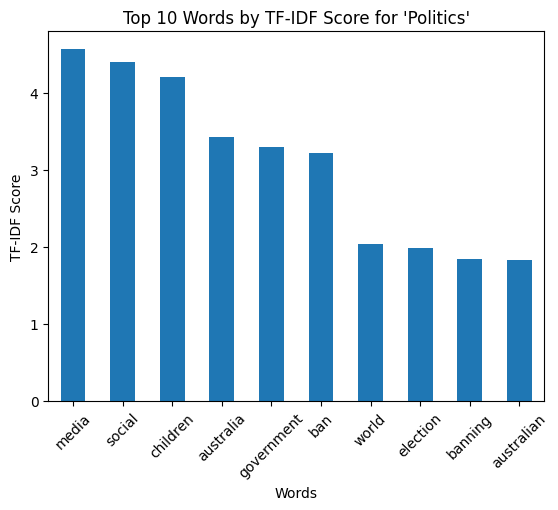

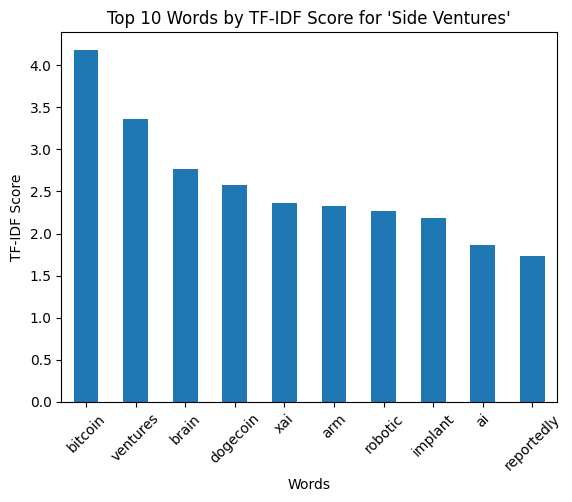

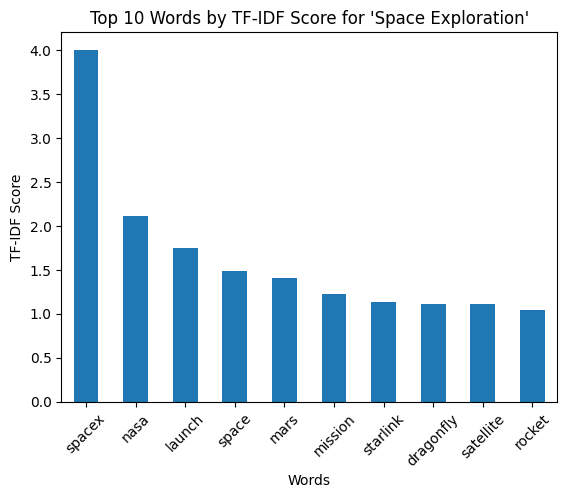

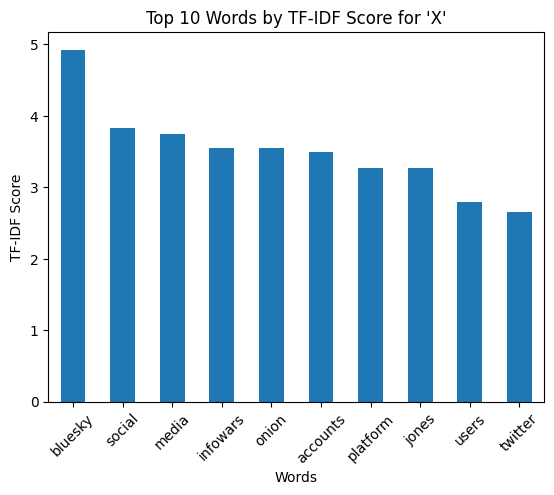

In [24]:
sums = tfidf_df.groupby(tfidf_df.index).sum()

category_scores = {
    category: sums.loc[category].nlargest(10)
    for category in sums.index
}

for category, scores in category_scores.items():
    scores.plot(kind='bar')
    plt.title(f"Top 10 Words by TF-IDF Score for '{category}'")
    plt.xlabel("Words")
    plt.ylabel("TF-IDF Score")
    plt.xticks(rotation=45)
    plt.show()